# **FORD BIKE SHARING PROJECT**

## PROJECT TYPE - PERFORMING EXPLORATORY DATA ANALYSIS

###  Contribution - Individual

# Project Summary 

#####                 The Ford GoBike system, launched in 2017, was a public bike-sharing program serving the San Francisco Bay Area, including San Francisco, Oakland, Berkeley, Emeryville, and San Jose.The system was designed to offer a sustainable, convenient, and affordable transportation option for both locals and visitors.
**Goals of the Ford GoBike Program :**
##### 1).Provide an affordable, flexible, and fast way to move around dense urban environments.
##### 2).Reduce traffic congestion and greenhouse gas emissions by replacing short car trips with bike rides.
##### 3).Increase physical activity by making biking a more accessible daily option.
##### 4).Offer discounted memberships through the Bike Share for All program for low-income residents.



## The project follows a structured data science approach:

 **Data Import & Exploration:**
                 The dataset is loaded into a pandas DataFrame, and initial inspection involves understanding the shape, structure, and distribution of key variables.

 **Data Cleaning:**
                 Duplicate entries are removed to ensure data accuracy. Missing values, especially in critical columns like member birth year, are handled.Data types of member_birth_year,start_time,end_time columns are changed.New columns are created as start_day,start_month and start_hr,end_day,end_month,end_hr are extracted from start_time and end_time column.

 **Univariate Analysis:** Univariate analysis involves examining each variable in a dataset individually.  The goal is to understand the distribution, central tendency, and spread of that variable.It is used to prepare the data for more complex, multivariate analysis

 **Bivariate Analysis:** Bivariate analysis is a step up from Univariate analysis and perfect for exploring relationships between two variables in Ford GoBike dataset.It is used to detect correlations between two variables.

 **Multivariate Analysis:** Multivariate analysis, which builds upon univariate and bivariate analysis to uncover deeper, more complex patterns in  Ford GoBike dataset. Multivariate analysis examines three or more variables simultaneously to understand relationships, interactions, and combined effects to identify hidden trends and patterns.

# *Let's Begin!*

## *1. Know Your Data*

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('classic') 

### Dataset Loading

In [3]:
df=pd.read_csv(r"C:\Users\91790\Desktop\JN_JUPYTER NOTEBOOK\201801-fordgobike-tripdata.csv")


### Dataset First View

In [4]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120,Mission Dolores Park,37.761420,-122.426435,285,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304,Jackson St at 5th St,37.348759,-121.894798,296,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75,Market St at Franklin St,37.773793,-122.421239,47,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74,Laguna St at Hayes St,37.776435,-122.426244,19,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


### Dataset Rows & Columns count

In [5]:
df.shape

(94802, 16)

### Drop Duplicates

In [6]:
df.drop_duplicates(inplace = True)
df.shape

(94802, 16)

### Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94802 entries, 0 to 94801
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   duration_sec             94802 non-null  int64  
 1   start_time               94802 non-null  object 
 2   end_time                 94802 non-null  object 
 3   start_station_id         94802 non-null  int64  
 4   start_station_name       94802 non-null  object 
 5   start_station_latitude   94802 non-null  float64
 6   start_station_longitude  94802 non-null  float64
 7   end_station_id           94802 non-null  int64  
 8   end_station_name         94802 non-null  object 
 9   end_station_latitude     94802 non-null  float64
 10  end_station_longitude    94802 non-null  float64
 11  bike_id                  94802 non-null  int64  
 12  user_type                94802 non-null  object 
 13  member_birth_year        86963 non-null  float64
 14  member_gender         

### *2. Understanding Your Variables*

### Dataset Columns

In [8]:
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')

### Dataset Describe

In [9]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,94802.000000,94802.000000,94802.000000,94802.000000,94802.00000,94802.000000,94802.000000,94802.000000,86963.000000
mean,870.935930,103.766302,37.773321,-122.361677,101.00982,37.773536,-122.360776,2048.751609,1980.932420
std,2550.596891,87.730464,0.085744,0.105253,86.77949,0.085552,0.104580,1091.507513,10.803017
min,61.000000,3.000000,37.317298,-122.444293,3.00000,37.317298,-122.444293,11.000000,1900.000000
25%,359.000000,30.000000,37.771662,-122.412408,27.00000,37.773063,-122.411306,1133.000000,1975.000000
50%,555.000000,79.000000,37.781270,-122.398773,76.00000,37.781752,-122.398436,2151.500000,1983.000000
75%,854.000000,160.000000,37.795392,-122.390428,157.00000,37.795392,-122.390428,3015.000000,1989.000000
max,85546.000000,342.000000,37.880222,-121.874119,342.00000,37.880222,-121.874119,3744.000000,2000.000000


### Checking Unique values for 'Start_time'

In [10]:
df['start_time'].unique()

array(['2018-01-31 22:52:35.2390', '2018-01-31 16:13:34.3510',
       '2018-01-31 14:23:55.8890', ..., '2018-01-01 00:09:31.7450',
       '2018-01-01 00:07:52.9430', '2018-01-01 00:07:41.0400'],
      shape=(94801,), dtype=object)

### Changing start_time,end_time column data types to 'datetime'

In [11]:
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')

### Extracting day,month and hr from start_time and end_time

In [12]:
import datetime as dt
df['start_day'] = df['start_time'].dt.day_name()
df['start_month'] = df['start_time'].dt.month_name()

df['start_hr'] = df['start_time'].dt.hour
df['start_hr'] = df.start_hr.astype(str)




df['end_day'] = df['end_time'].dt.day_name()
df['end_month'] =df['end_time'].dt.month_name()
df['end_hr'] = df['end_time'].dt.hour
df['end_hr'] = df.end_hr.astype(str)

### Checking Unique values for 'member_year_birth'

In [13]:
df['member_birth_year'].unique()

array([1986.,   nan, 1996., 1991., 1988., 1980., 1987., 1994., 1993.,
       1957., 1976., 1964., 1995., 1997., 1983., 1945., 1971., 1975.,
       1978., 1981., 1990., 1970., 1992., 1989., 1982., 1985., 1966.,
       1998., 1973., 1979., 1956., 1984., 1911., 1951., 1965., 1963.,
       1972., 1969., 1968., 1977., 1959., 1960., 1943., 1958., 1974.,
       1999., 1967., 1936., 1954., 1955., 1962., 1961., 1949., 1942.,
       1902., 1950., 1947., 1940., 1948., 1952., 1944., 1935., 1953.,
       1934., 1900., 1928., 1933., 1924., 1938., 1941., 1946., 1939.,
       2000.])

### Displays counts of Null values

In [14]:
 df['member_birth_year'].isna().sum()

np.int64(7839)

### Dropping null values

In [15]:
df = df.dropna(subset=['member_birth_year'])
df['member_birth_year'] = df['member_birth_year'].astype(int)

#### The above procedure shows cleaning process have been completed.First dataset information has been displayed,we came to observed that there are some of the null values are present on 'member_year_birth' column.Null values are removed.Duplicates are dropped.Data types are also changed for both 'start_time' and 'end_time' column.New columns are created to display hour,day and month.This cleaned process will further be useful for the anlaysis of this project.

## *3. Data Vizualization & Experimenting with charts : Understand the relationships between variables*

## **Univariate Analysis**

### Chart 1: Histogram

### Calculation of Average trip duration

Average Trip Duration: 728.39 seconds


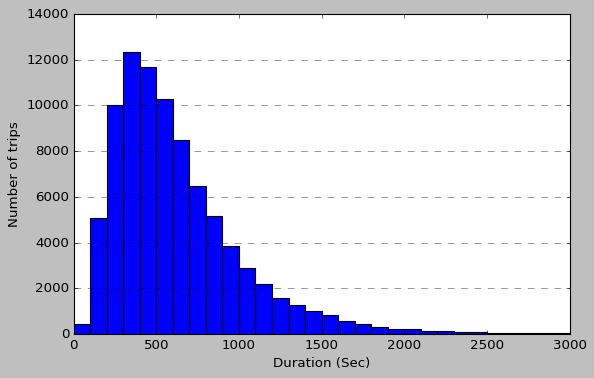

In [16]:
binsize = 100
bins = np.arange(0, df['duration_sec'].max()+binsize, binsize)

average_duration = df['duration_sec'].mean()
print(f"Average Trip Duration: {average_duration:.2f} seconds")


plt.figure(figsize=[8, 5])
plt.hist(data = df, x = 'duration_sec', bins=bins)
plt.xlabel('Duration (Sec)')
plt.ylabel('Number of trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim([0, 3000]);

##### The above plot shows the calculation of Average trip duration(secs).
##### It is plotted with Histogram and Number of trips is displayed.
##### First bin size is kept for 'duration_sec'.In this graph,the bin size of(300-400)duration secs and (400-500)duration secs,the trip taken between these bins size is more when compared to other duration_secs.
##### If, duration_secs gets increased,the number of trips taken gets reduced.
##### It shows only shorter trips are taken continuously,as longer trips are taken occasionally.

### Chart 2 : Countplot

### Distribution of Rides by Days 

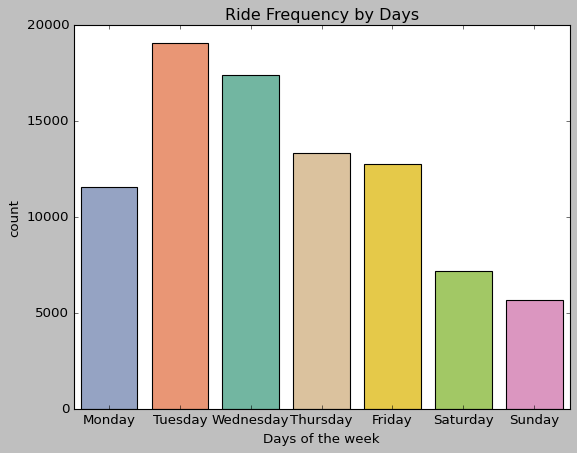

In [17]:
plt.figure(figsize = (8,6))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data = df, x = 'start_day',  hue='start_day',palette='Set2',order=order)
plt.xlabel('Days of the week')
plt.title('Ride Frequency by Days');

##### The above plot shows the count of No. of trips taken in weeks.
##### The No. of trips taken on weekdays is higher as compared to weekends.

### Distribution of Rides by Hours

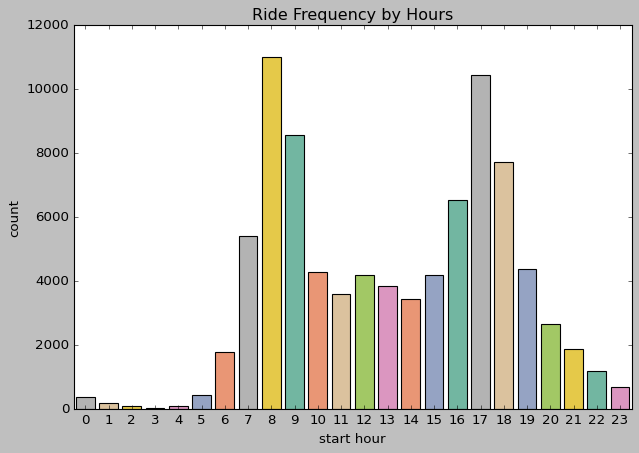

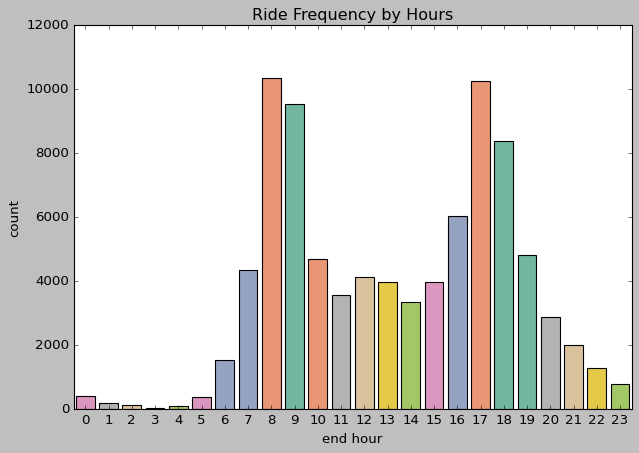

In [18]:
plt.figure(figsize = (9,6))
order=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]
sns.countplot(data = df, x = 'start_hr',  hue='start_hr',palette='Set2',order=order)
plt.xlabel('start hour')
plt.title('Ride Frequency by Hours');


plt.figure(figsize = (9,6))
order=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]
sns.countplot(data = df, x = 'end_hr',  hue='end_hr',palette='Set2',order=order)
plt.xlabel('end hour')
plt.title('Ride Frequency by Hours');

##### The above chart shows no. of trips taken on start_hr and end_hr.
##### The higher ride frequencies for morning (8th and 9th hours) and evening (17th and 18th hours) can be linked to rush hours where people leave for work and come back later in the evening.
##### The 3rd and 4th hours have the least trip records shows its an early morning.


### Distribution of User type,Member type and Bike share for all trip

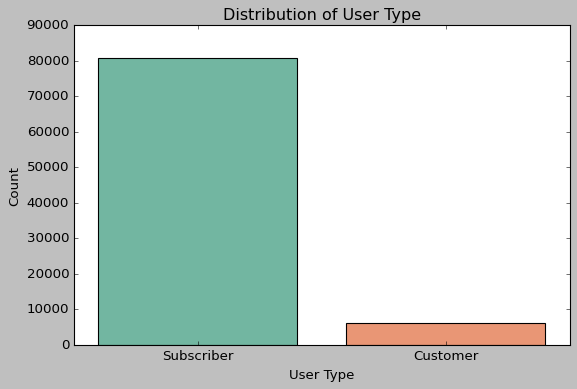

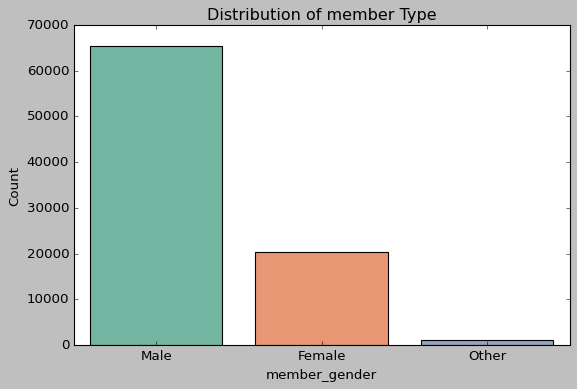

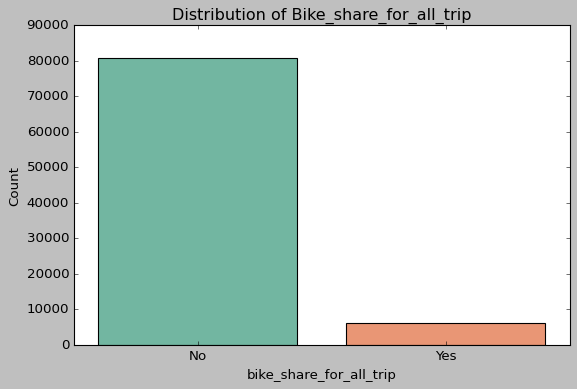

In [19]:
user_type_counts = df['user_type'].value_counts()
# Plotting count plot
plt.figure(figsize=(8, 5))
sns.countplot(x='user_type', data=df,hue='user_type', palette='Set2')
plt.title('Distribution of User Type')
plt.xlabel('User Type')
plt.ylabel('Count') 
plt.show()


df['member_gender'].value_counts()
# Plotting count plot
plt.figure(figsize=(8, 5))
sns.countplot(x='member_gender', data=df,hue='member_gender', palette='Set2')
plt.title('Distribution of member Type')
plt.xlabel('member_gender')
plt.ylabel('Count')
plt.show()


df['bike_share_for_all_trip'].value_counts()
# Plotting count plot
plt.figure(figsize=(8, 5))
sns.countplot(x='bike_share_for_all_trip', data=df,hue='bike_share_for_all_trip', palette='Set2')
plt.title('Distribution of Bike_share_for_all_trip')
plt.xlabel('bike_share_for_all_trip')
plt.ylabel('Count')
plt.show()


##### **Distribution of User type**
 ##### First count of user type is calculated.Here,Subscriber count is very high as Customer count is very less.


##### **Distribution of Member type**
##### Here,member type of male is very high which means, no. of trips are taken mostly by male compared to female and other gender types.

##### **Distribution of Bike share for all trip**
##### The above count plot displays that count of bike sharing for all trips are very less .

## **Bivariate analysis**


### Chart 3: Boxplot

### Trip Duration Vs. Gender, User type, Bike share for all trip

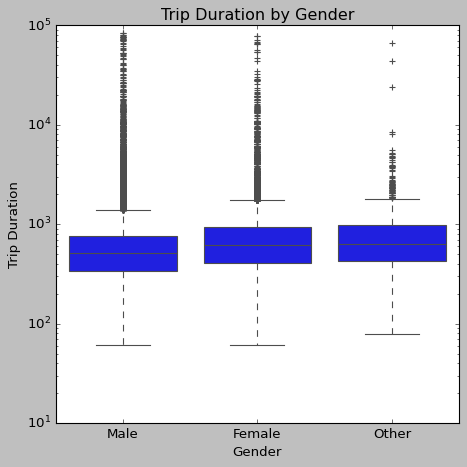

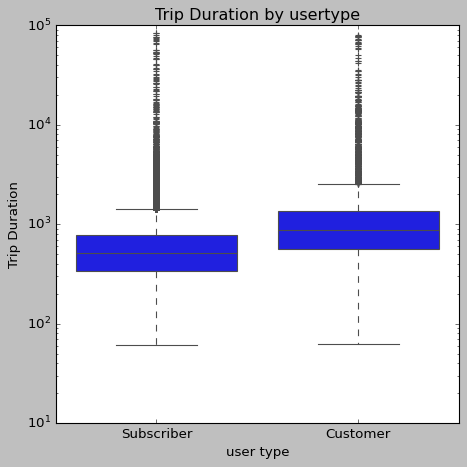

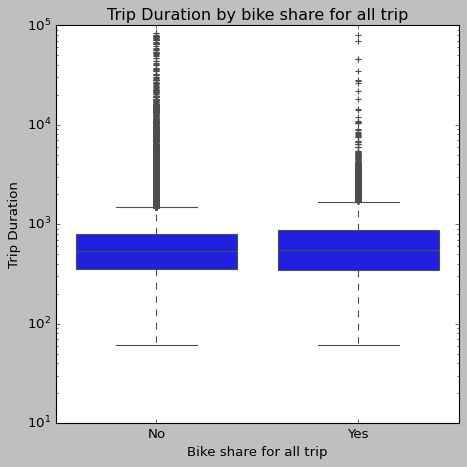

In [20]:
# Create a boxplot of duration_sec by member_gender
plt.figure(figsize=(6, 6))
sns.boxplot(x='member_gender', y='duration_sec', data=df)
plt.yscale("log")  # Log scale to handle skewed distribution
plt.title('Trip Duration by Gender')
plt.xlabel('Gender')
plt.ylabel('Trip Duration')
plt.tight_layout()
plt.show()



# Create a boxplot of duration_sec by user_type
plt.figure(figsize=(6, 6))
sns.boxplot(x='user_type', y='duration_sec', data=df)
plt.yscale("log")  # Log scale to handle skewed distribution
plt.title('Trip Duration by usertype')
plt.xlabel('user type')
plt.ylabel('Trip Duration')
plt.tight_layout()
plt.show()



# Create a boxplot of duration_sec by bike_share_for_all_trip
plt.figure(figsize=(6, 6))
sns.boxplot(x='bike_share_for_all_trip', y='duration_sec', data=df)
plt.yscale("log")  # Log scale to handle skewed distribution
plt.title('Trip Duration by bike share for all trip')
plt.xlabel('Bike share for all trip')
plt.ylabel('Trip Duration')
plt.tight_layout()
plt.show()


##### **Trip duration by Gender**
#####  This box plot shows the distribution of trip durations for each gender in the dataset.Each box shows the interquartile range (IQR) — from the 25th percentile to the 75th.The line inside the box is the median trip duration.Whiskers extend to show the range (excluding outliers).Dots above the whiskers are outliers.
##### Males tend to take shorter trips on average compared to Females and Others.



##### **Trip duration by usertype**
##### This boxplot shows distribution of trip durations for user type in dataset. Subscribers generally have shorter and more consistent trip durations, while Customers may have longer and more varied trips.

##### **Trip duration by Bike share for all trip**
##### This box plot shows distribution of trip durations based on bike sharing for all the trips.Here, the duration of bike sharing and non bike sharing is almost more or less seems to be same.


### Chart 4: Lineplot

### Number of trip Vs. Date

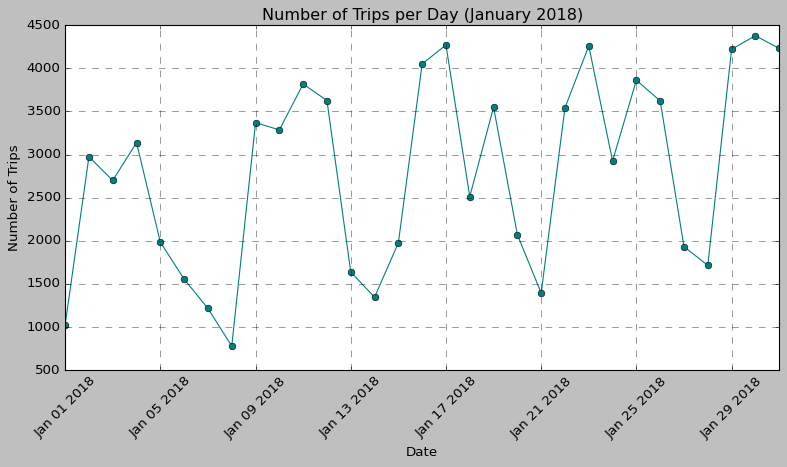

In [21]:
# Group by date and count trips
daily_trips = df.groupby(df['start_time'].dt.date).size()

# Plotting the number of trips per day
plt.figure(figsize=(10, 6))
daily_trips.plot(kind='line', marker='o', color='teal')
plt.title('Number of Trips per Day (January 2018)')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### The line graph itself shows the trend of trips over the course of January 2018.Each circle marker (marker='o') on the line represents the number of trips on a specific day.The line connects these data points to show the change in the number of trips over time.Peaks where trips were particularly high on certain days (maybe a holiday or weekend).Though trips were lower (possibly weekdays or slower days).If you notice a spike in the number of trips on January 1st, you might deduce that it's a holiday, and more people took trips that day.If you see a steady drop in trips from January 1st to January 10th, it might suggest that trips slowed down after the start of the year, or fewer people were taking trips during that period.This chart is helpful for visualizing time-based trends in a simple, understandable way.

### Chart 5: Boxplot

### Trip duration Vs. Start_day and End_day

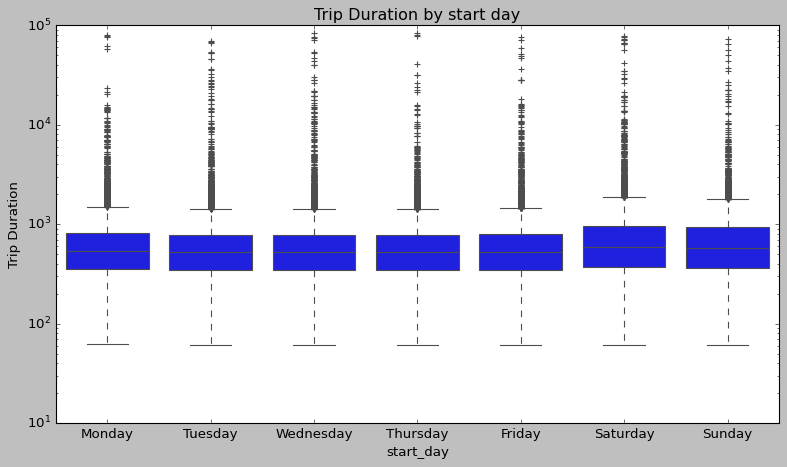

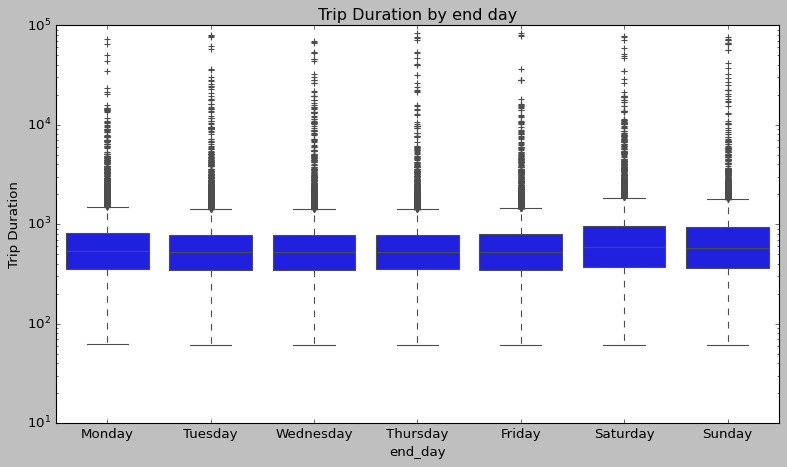

In [22]:
plt.figure(figsize=(10, 6))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='start_day', y='duration_sec', data=df,order=order)
plt.yscale("log")  # Log scale to handle skewed distribution
plt.title('Trip Duration by start day')
plt.xlabel('start_day')
plt.ylabel('Trip Duration')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='end_day', y='duration_sec', data=df,order=order)
plt.yscale("log")  # Log scale to handle skewed distribution
plt.title('Trip Duration by end day')
plt.xlabel('end_day')
plt.ylabel('Trip Duration')
plt.tight_layout()
plt.show()

##### The above box plot shows relation between trip duration and start_day  and end_day.
##### Interestingly, it appears that there is a positive relationships between the trip duration and days of the week.The average trip durations increases from monday through Sunday.The duration of trip in weekend is high as comapared to weekdays. 


### Chart 6: Subplot

### User type vs Bike share for all trip, Start_day vs. User type, User_type vs. Member_gender

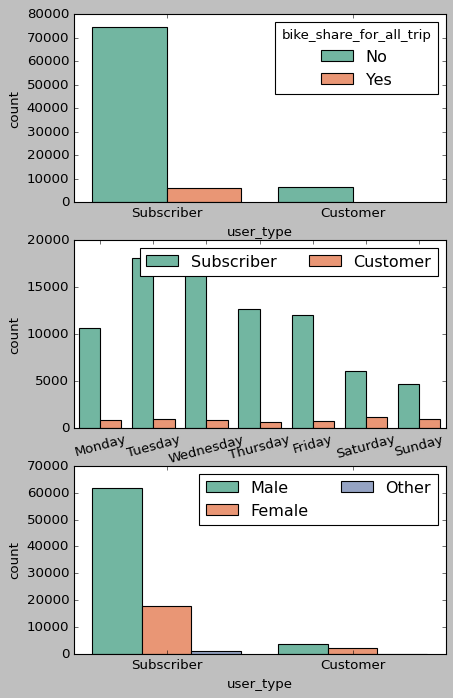

In [23]:
plt.figure(figsize = [6, 10])
# subplot 1: user_type vs bike_share_for_all_trip
plt.subplot(3, 1, 1)
sns.countplot(data = df, x = 'user_type', hue = 'bike_share_for_all_trip', order=df.user_type.value_counts().index,
             palette = 'Set2')



# subplot 2: start_day vs. user_type
ax = plt.subplot(3, 1, 2)
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data = df, x = 'start_day', hue = 'user_type', palette = 'Set2',order=order)
ax.legend(ncol = 2) # re-arrange legend to reduce overlapping
plt.xticks(rotation=15)



# subplot 3: user_type vs. member_gender, 
ax = plt.subplot(3, 1, 3)
sns.countplot(data = df, x = 'user_type', hue = 'member_gender',order=df.user_type.value_counts().index,
             palette = 'Set2')
ax.legend(loc = 1, ncol = 2) # re-arrange legend to remove overlapping
plt.show()

##### **User Type vs. Bike Share for All Trip**
##### The above subplot shows relationship between user tyoe and bike share for all trip. Here Subscribers are in majority of users.Most people, even among Subscribers, might not be enrolled in the “Bike Share for All” program .


##### **Start day vs. User type**
##### This graph shows,number of rides started each day of the week.Subscribers likely use bikes more during weekdays.Customers might use bikes more on weekends.

##### **User_type vs. Member_gender**
##### This subplot shows Gender distribution.Here,gender of male tends to be high as they are subscribers as compared to female and others.

## **Multivariate Analysis**

### Chart 7: Pointplot

### Trip duration across week days and user type

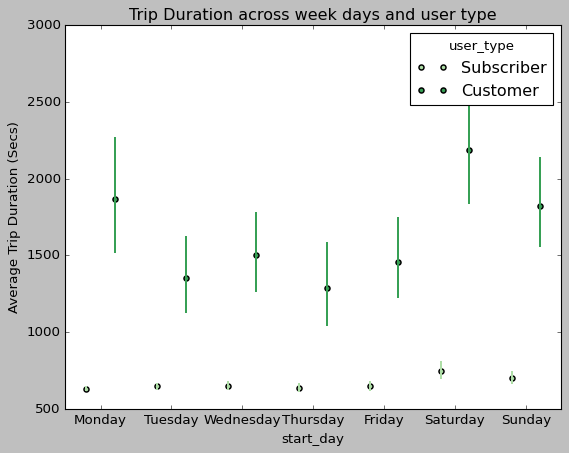

In [24]:
fig = plt.figure(figsize = [8,6])
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ax = sns.pointplot(data = df, x ='start_day', y = 'duration_sec', hue = 'user_type',
           palette = 'Greens', linestyles = '', dodge = 0.4,order=order)
plt.title('Trip Duration across week days and user type')
plt.ylabel('Average Trip Duration (Secs)')
plt.show();

##### The above graph shows point plot for trip duration across week days and user type.
##### Customers travel very longer distance on weekends whereas subscribers generally travel short distance with little increase on weekends but not up to that of the customers.


### Trip duration across gender and bike share for all trip


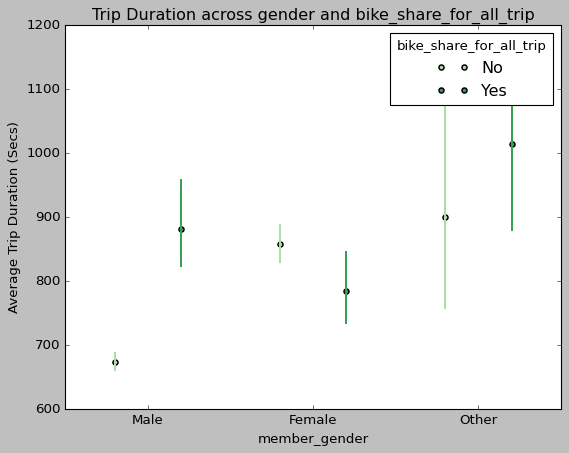

In [25]:
fig = plt.figure(figsize = [8,6])
ax = sns.pointplot(data = df, x ='member_gender', y = 'duration_sec', hue = 'bike_share_for_all_trip',
           palette = 'Greens', linestyles = '', dodge = 0.4)
plt.title('Trip Duration across gender and bike_share_for_all_trip')
plt.ylabel('Average Trip Duration (Secs)')
plt.show();

##### The above point plot shows relation between gender and bike share for all trip and trip duration.The other gender group travels for the longest duration for bike sharing and non bike sharing, followed by female, then male.


### Trip duration across gender and user type 

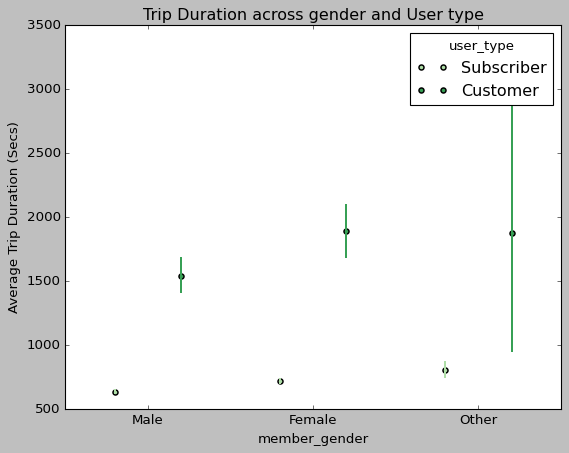

In [26]:
fig = plt.figure(figsize = [8,6])
ax = sns.pointplot(data = df, x ='member_gender', y = 'duration_sec', hue = 'user_type',
           palette = 'Greens', linestyles = '', dodge = 0.4)
plt.title('Trip Duration across gender and User type')
plt.ylabel('Average Trip Duration (Secs)')
plt.show();

#####  The above point plot shows relation between gender and user type.For both subscribers and customers, the other gender group spent most duration followed by female and then male.


## **Conclusion**

##### The dataset is just for the months of Januaury.
##### Most trips were taken on tuesday and wednesdays.
##### The rush hours going to work in the morning (8 and 9 hrs) and closing in the evening (17 and 18 hrs) have the highest trip records.
##### About 90% of the trips were taken by subscribers.
##### Less than 10% of the trips were bike sharing for all trips.
##### Most of the trips were taken by males .
##### Customers spend more duration than subscribers.
##### Females spend more duration than males.
##### Trip durations on weekends are longer than on other weekdays.
##### Only subscribers are allowed to share bikes on trips.




